In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import csv
import pandas as pd
import os
import numpy as np

In [ ]:
NUM_TOPICS = 3
CONFIRMATION_BIAS = True
ALPHA_CB = 5.0

In [4]:
G = nx.DiGraph()

with open("D:/SEM VI/Project/Dataset/edges.csv", "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        G.add_edge(
            int(row["u"]),
            int(row["v"]),
            trust=float(row["trust"])
        )

In [5]:
with open("D:/SEM VI/Project/Dataset/nodes1.csv", "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        node = int(row["node"])
        threshold = float(row["threshold"])
        opinion = np.array([
            float(row["op1"]),
            float(row["op2"]),
            float(row["op3"])
        ])

        G.add_node(node)
        G.nodes[node]["threshold"] = threshold
        G.nodes[node]["opinion"] = opinion


In [ ]:
def confirmation_weight(x_u, x_v, alpha=ALPHA_CB):
    return np.exp(-alpha * np.linalg.norm(x_u - x_v))

In [7]:
def directed_multi_opinion_step(G):
    prev_opinion = {
        n: G.nodes[n]["opinion"].copy()
        for n in G.nodes()
    }
    updates = {}

    for v in G.nodes():
        incoming = list(G.predecessors(v))
        if not incoming:
            continue

        num = np.zeros(NUM_TOPICS)
        den = 0.0
        x_v = prev_opinion[v]

        for u in incoming:
            x_u = prev_opinion[u]
            trust = G.edges[u, v]["trust"]

            if CONFIRMATION_BIAS:
                trust *= confirmation_weight(x_u, x_v)

            num += trust * x_u
            den += trust

        if den == 0:
            continue

        new_opinion = num / den

        # threshold check (vector-wise movement)
        if np.linalg.norm(new_opinion - x_v) >= G.nodes[v]["threshold"]:
            updates[v] = new_opinion

    return updates, prev_opinion


In [8]:
def export_to_excel(G, iteration, prev_opinion,
                    out_dir="D:/SEM VI/Project/Dataset/updateexcel"):
    os.makedirs(out_dir, exist_ok=True)

    node_rows = []
    for n in G.nodes():
        node_rows.append({
            "node": n,
            "opinion_prev": prev_opinion[n].tolist(),
            "opinion_curr": G.nodes[n]["opinion"].tolist(),
            "opinion_changed": not np.allclose(
                prev_opinion[n], G.nodes[n]["opinion"]
            ),
            "threshold": G.nodes[n]["threshold"],
            "iteration": iteration
        })

    pd.DataFrame(node_rows).to_excel(
        f"{out_dir}/nodes_iter_{iteration}.xlsx",
        index=False
    )

    edge_rows = [
        {"source": u, "target": v, "trust": G.edges[u, v]["trust"]}
        for u, v in G.edges()
    ]

    pd.DataFrame(edge_rows).to_excel(
        f"{out_dir}/edges_iter_{iteration}.xlsx",
        index=False
    )


In [9]:
pos = nx.spring_layout(G, seed=42)

def plot_iteration(G, iteration):
    colors = [
        plt.cm.viridis(G.nodes[n]["opinion"][0])
        for n in G.nodes()
    ]

    labels = {
        n: f"{n}\n{np.round(G.nodes[n]['opinion'],2)}"
        for n in G.nodes()
    }

    plt.figure(figsize=(8, 8))
    nx.draw(G, pos, node_color=colors, node_size=800, arrows=True)
    nx.draw_networkx_labels(G, pos, labels, font_size=8)
    plt.title(f"Iteration {iteration}")
    plt.show()


Iteration 1: 39 real opinion changes


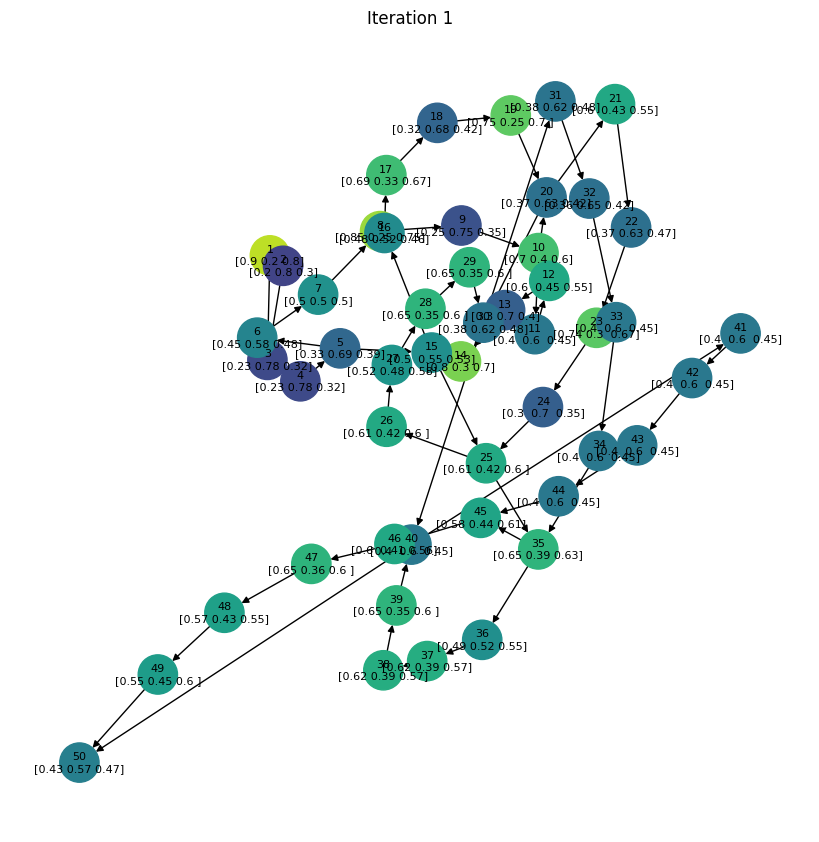

Iteration 2: 35 real opinion changes


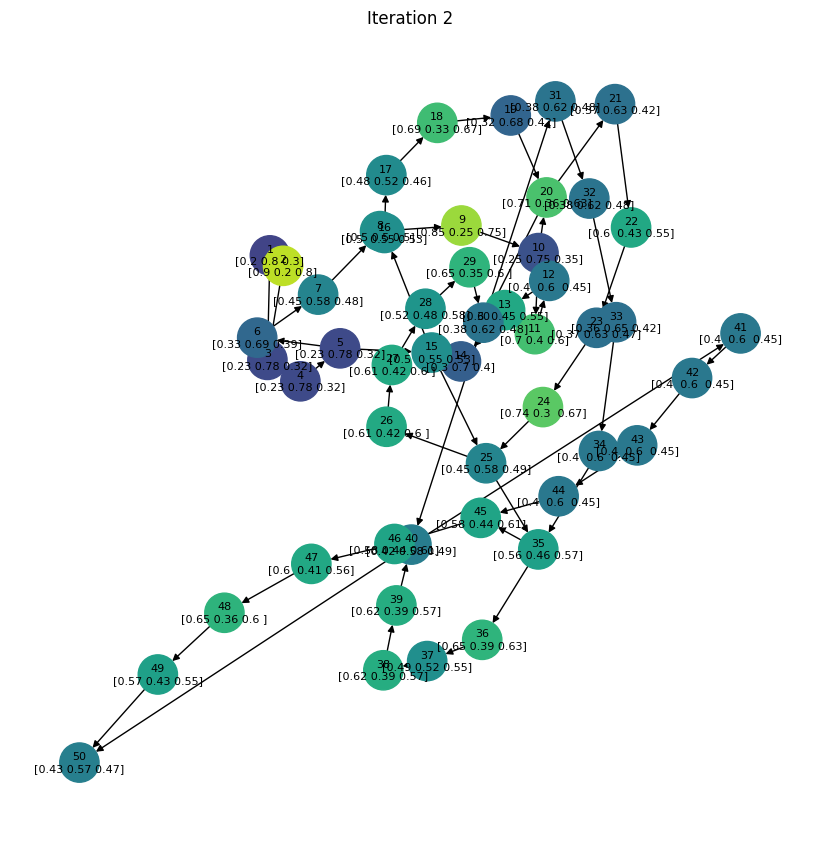

Iteration 3: 37 real opinion changes


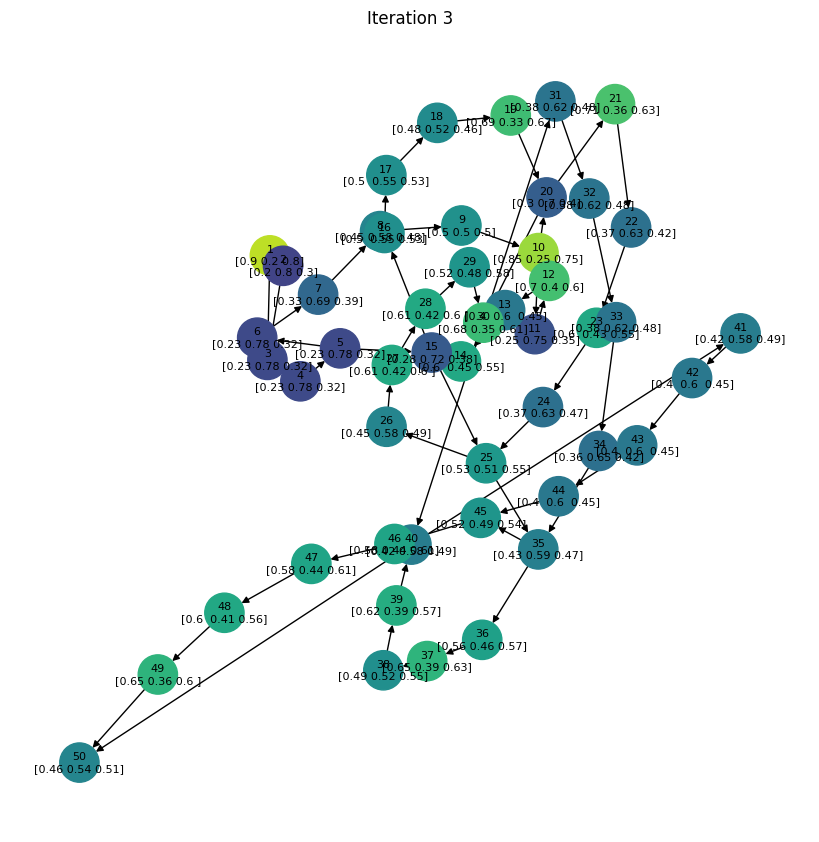

Iteration 4: 35 real opinion changes


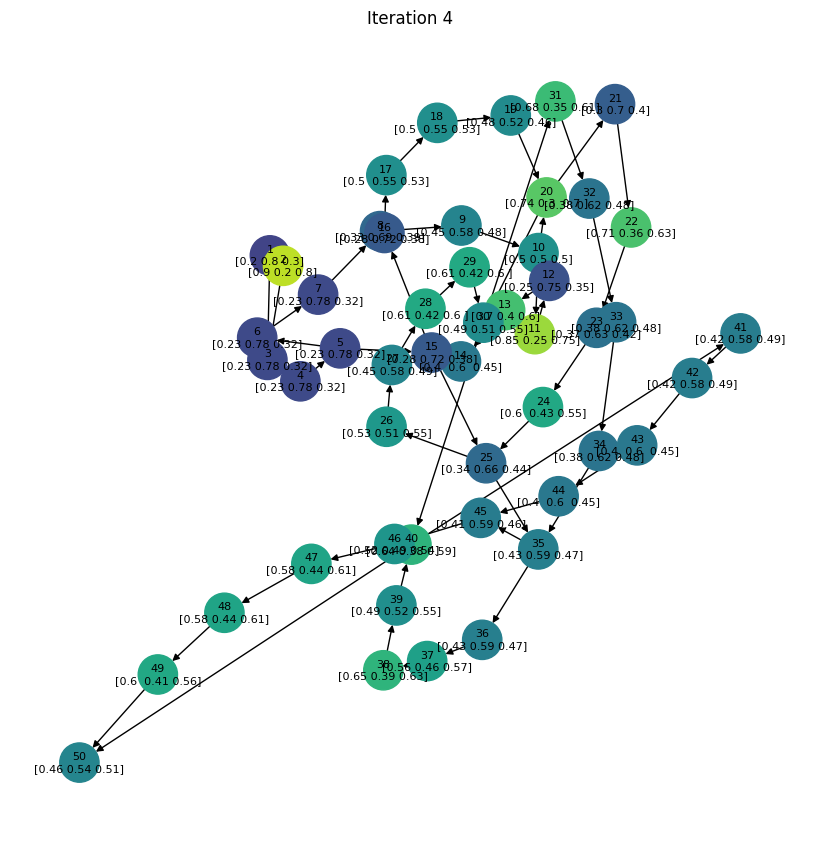

Iteration 5: 33 real opinion changes


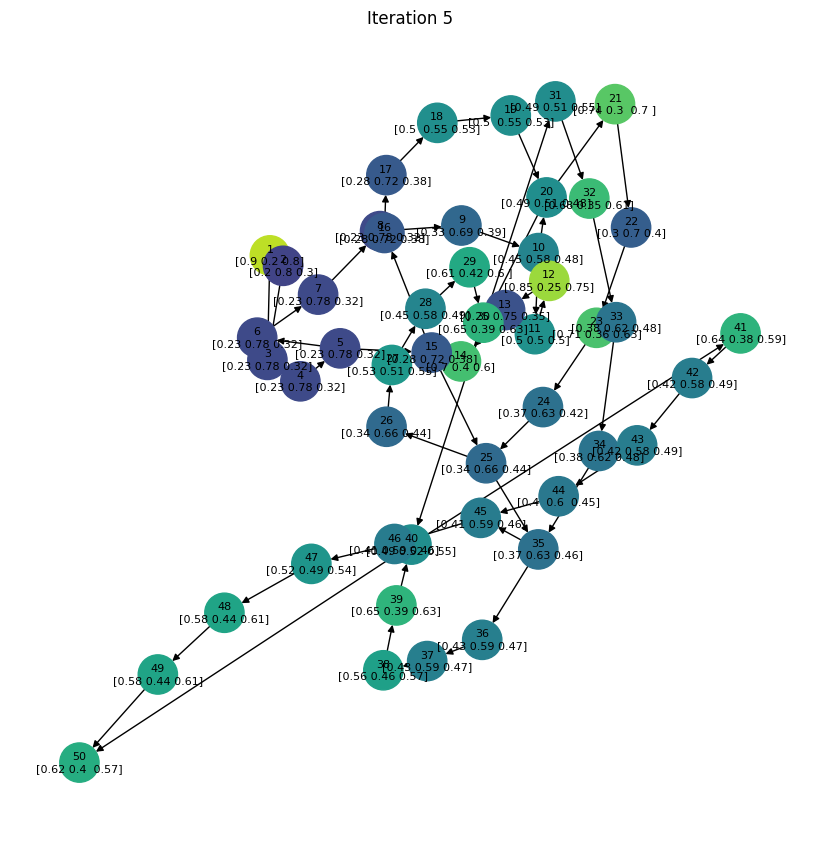

Iteration 6: 31 real opinion changes


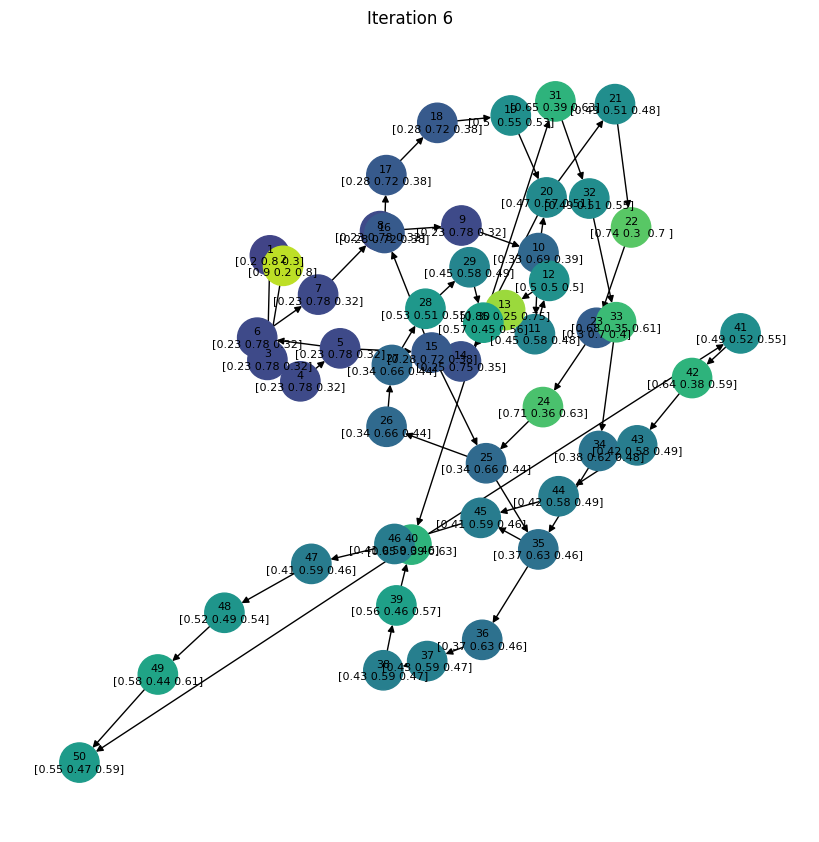

Iteration 7: 29 real opinion changes


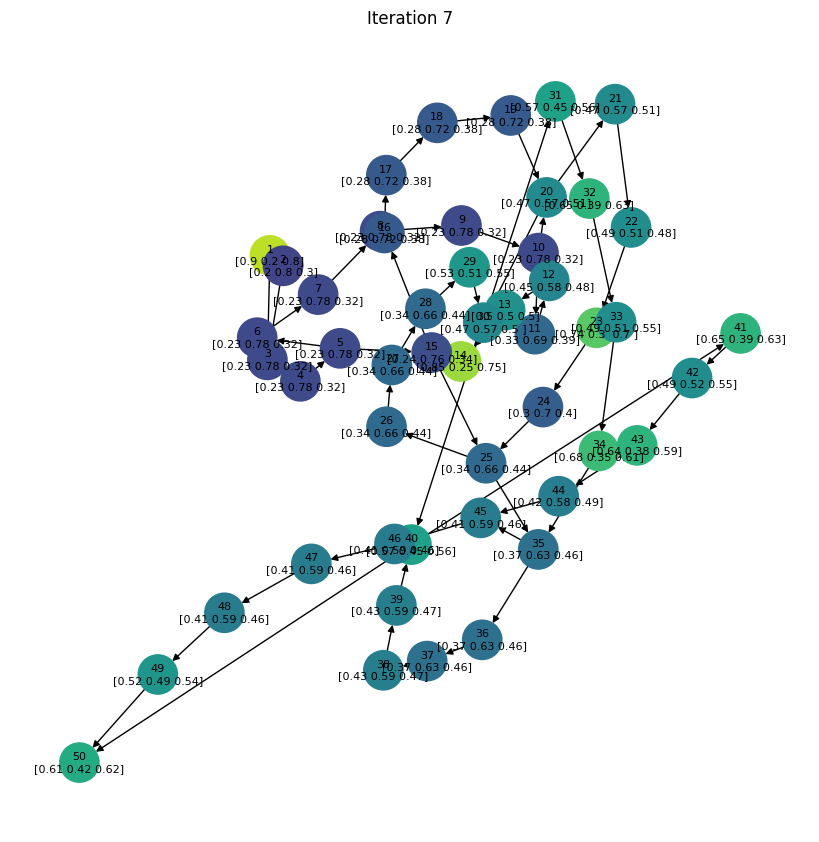

Iteration 8: 25 real opinion changes


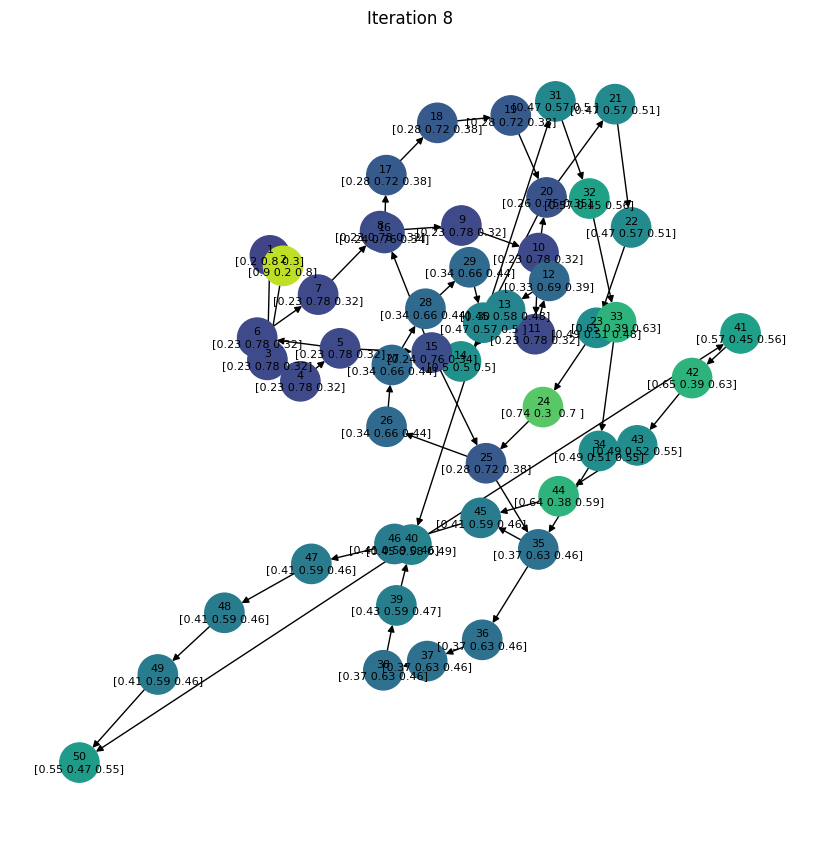

Iteration 9: 20 real opinion changes


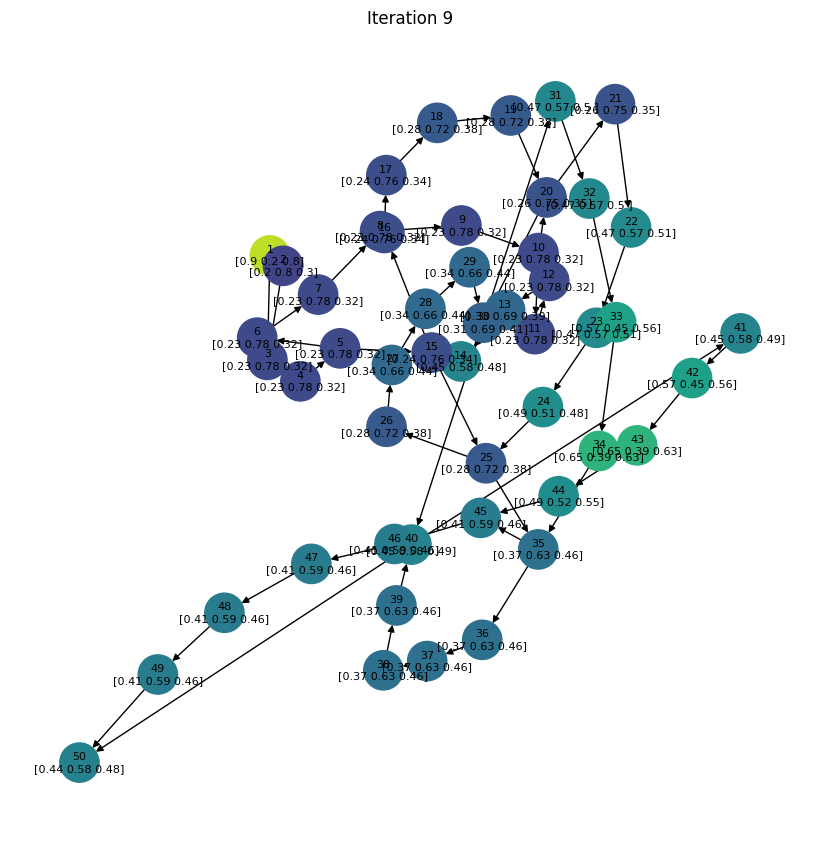

Iteration 10: 15 real opinion changes


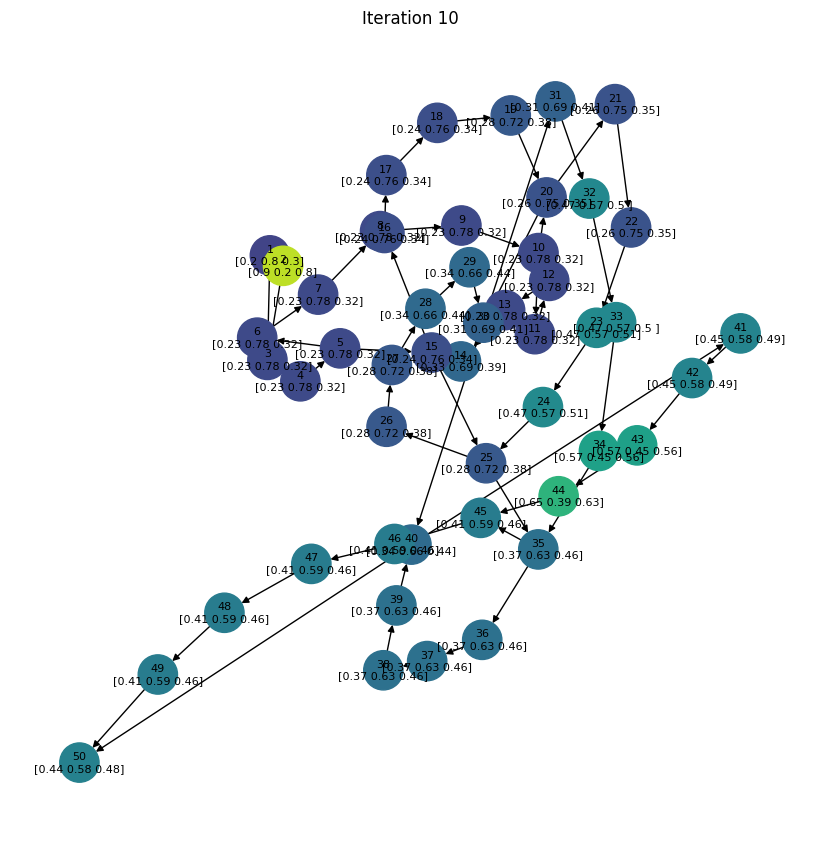

In [13]:
MAX_ITER = 10

for i in range(1, MAX_ITER + 1):
    updates, prev_opinion = directed_multi_opinion_step(G)

    real_changes = {
        n: op for n, op in updates.items()
        if not np.allclose(prev_opinion[n], op)
    }

    print(f"Iteration {i}: {len(real_changes)} real opinion changes")

    if not real_changes:
        print("No new opinion changes. Converged.")
        export_to_excel(G, i, prev_opinion)
        plot_iteration(G, i)
        break

    for n, op in real_changes.items():
        G.nodes[n]["opinion"] = op

    export_to_excel(G, i, prev_opinion)
    plot_iteration(G, i)
